In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import time

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot

In [2]:
model = torch.load('../../models/baselines/tesla_kind_trans.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var): Linear(in_features=8, out_features=8, bias=False)
    (pre_mean_dec): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=Tru

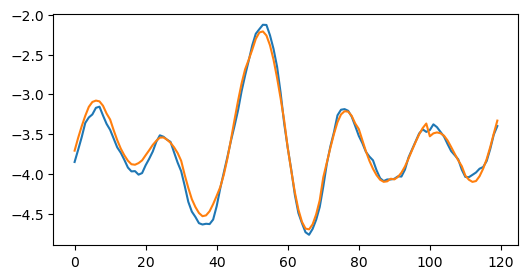

In [8]:
datadir            = '../../data/baselines/tesla_test'
timeseries_nsample = 250_000
timeseries         = utils_data.read_datafile(f'{datadir}/eval', timeseries_nsample)
timeseries         = timeseries.reshape(-1, timeseries.shape[-1])

j                  = 242_952
timeseries         = timeseries[j:j+120, :]
model_i            = torch.unsqueeze(timeseries[:80, :], 0)
model_o            = model(model_i)

blend              = torch.squeeze(model_o[0], dim=0)
stat               = torch.squeeze(model_o[1], dim=0)
trans              = torch.squeeze(model_o[3], dim=0)

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.plot(timeseries, color='tab:blue')
    plt.plot(blend, color='tab:orange')
    plt.show()

In [4]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/tesla_test'
timeseries_nsample = 250_000

mse_stat, mse_trans, mse_blend = utils_plot.plot_mse(model, datadir, timeseries_nsample)


inf >> forecasting results:

         mse      index      value
 -----------   --------   --------
  best blend     154525      0.001
 worst blend      34407      1.137
   avg blend         na      0.081
                                  
   best stat     219569      0.005
  worst stat      81688      8.983
    avg stat         na      0.469
                                  
  best trans     168100      0.001
 worst trans      27417      1.177
   avg trans         na      0.076

inf >> mean alpha is 0.17



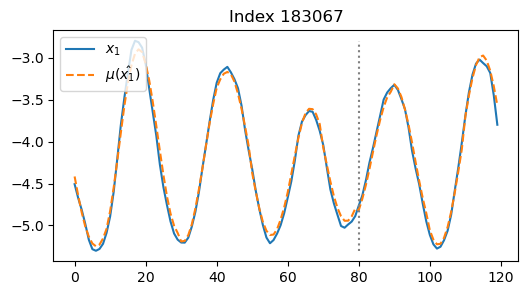

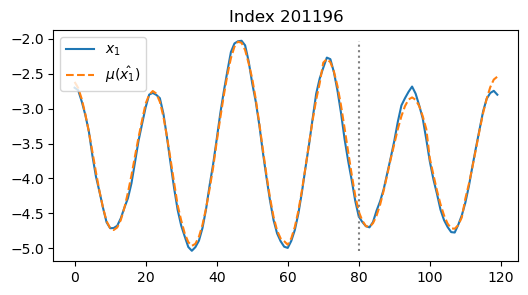

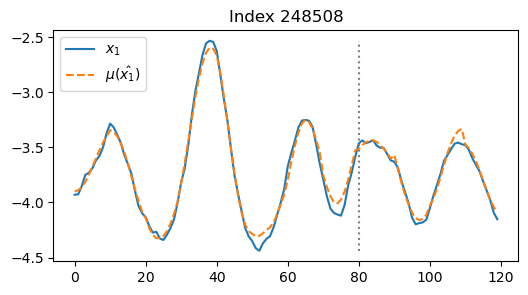

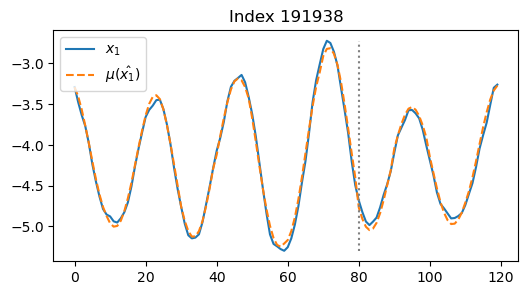

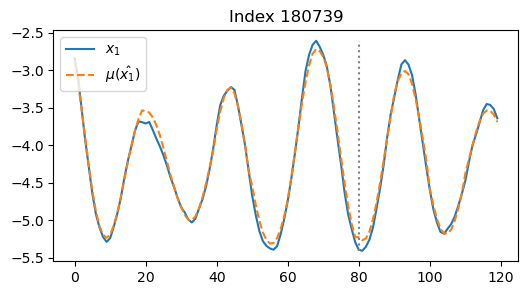

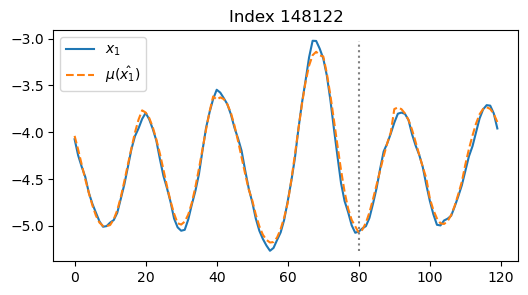

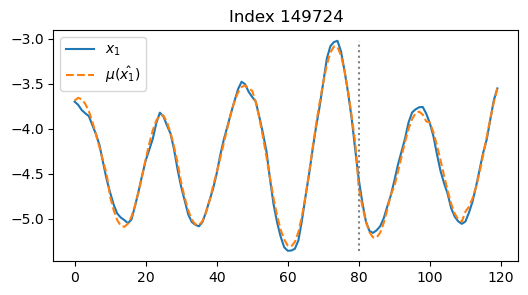

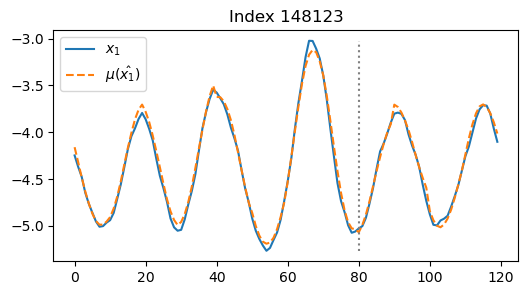

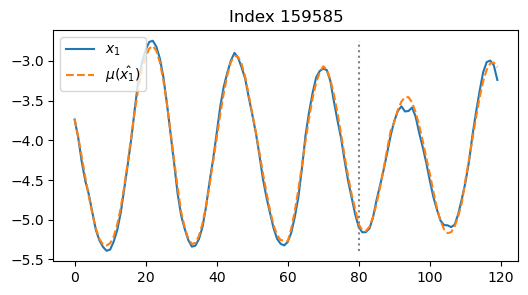

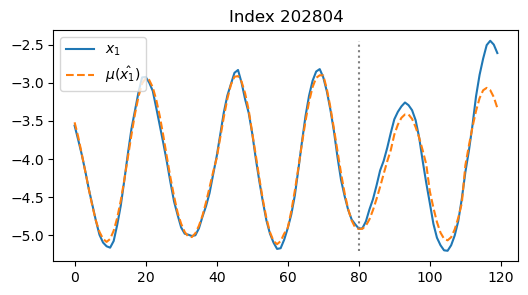

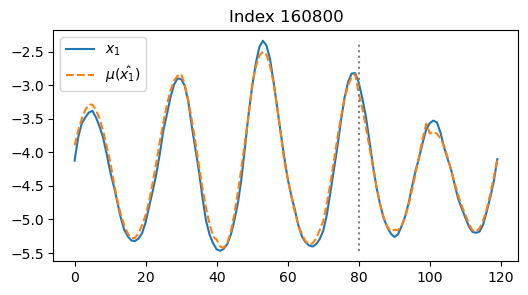

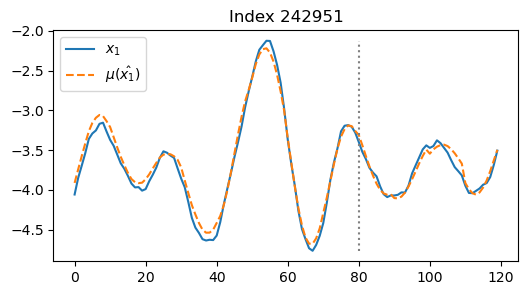

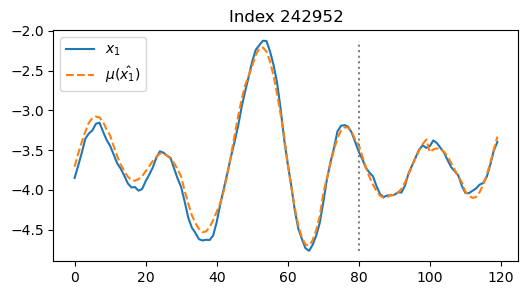

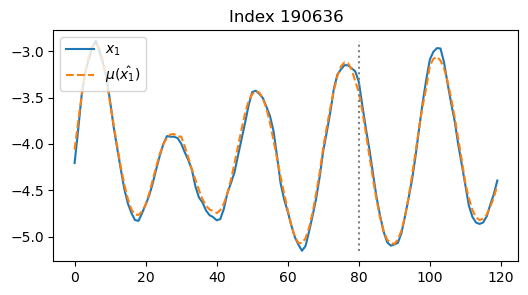

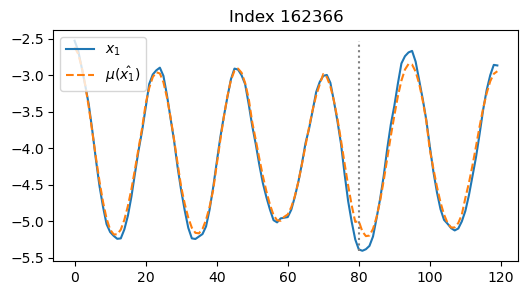

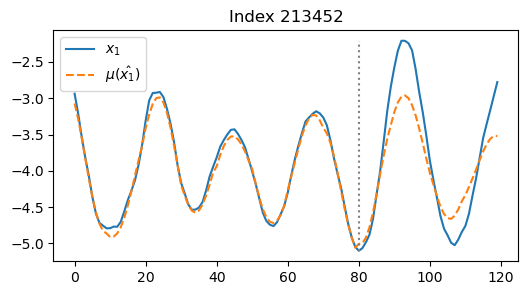

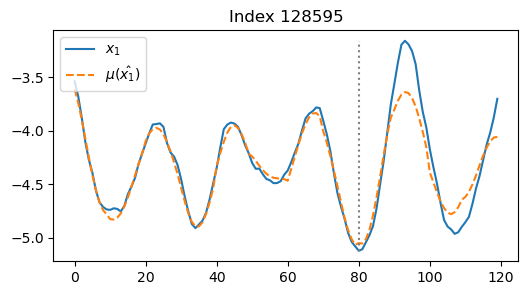

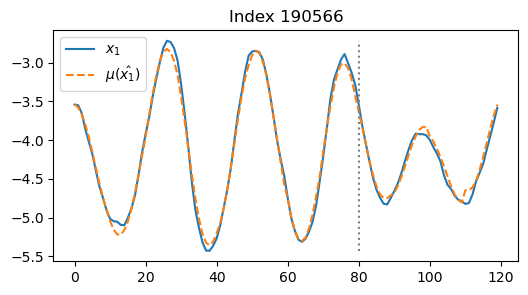

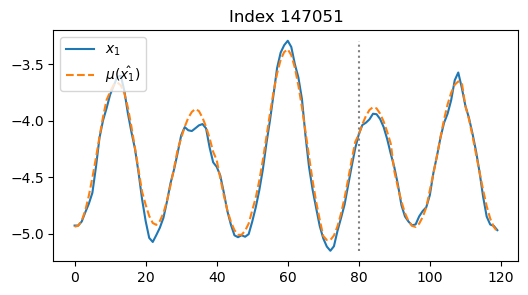

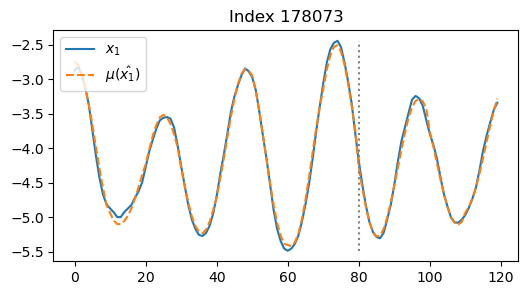

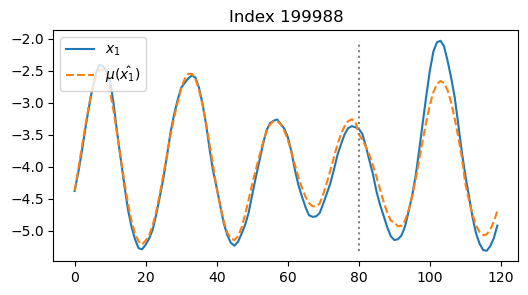

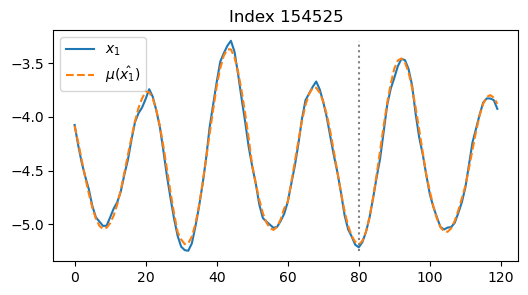

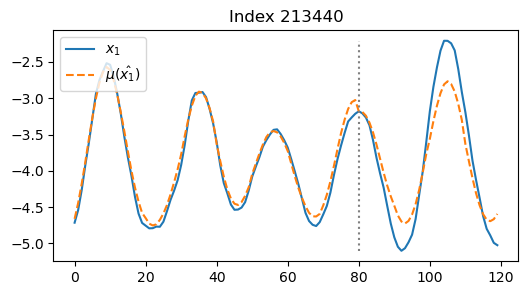

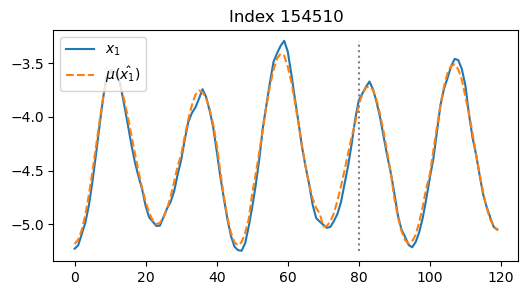

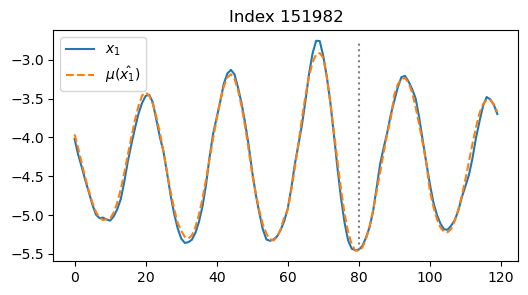

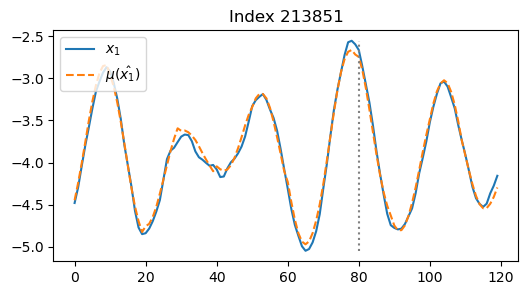

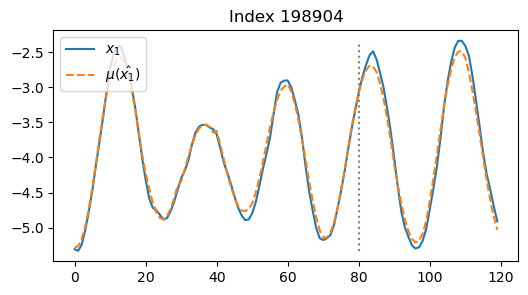

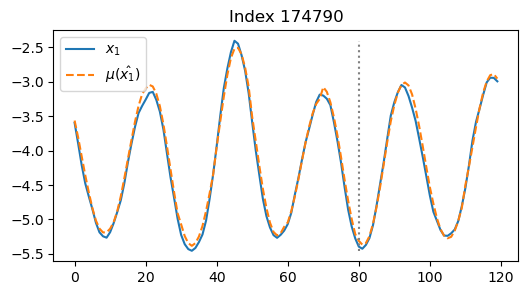

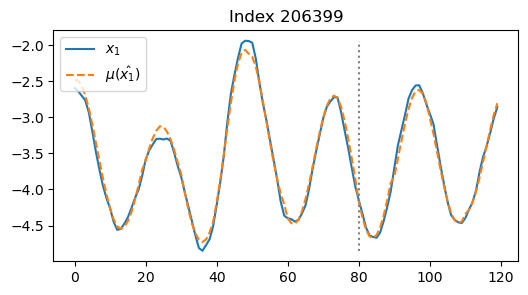

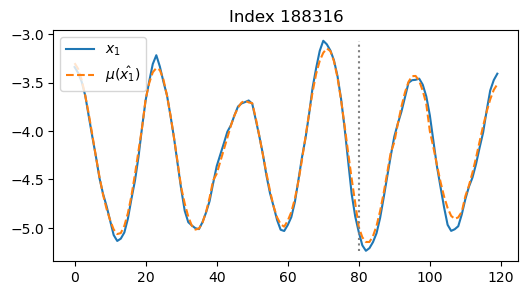

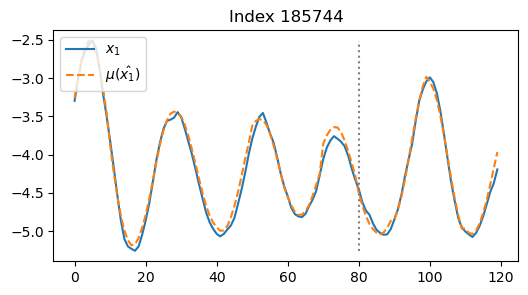

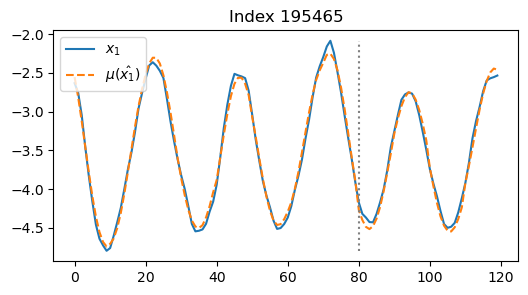

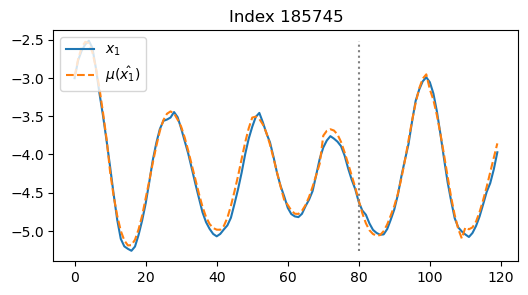

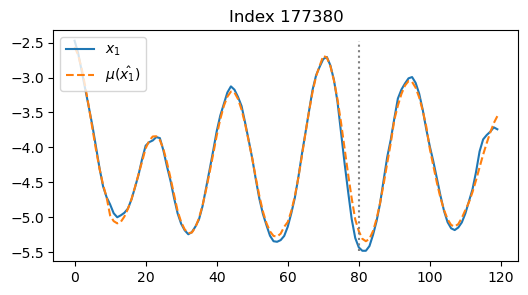

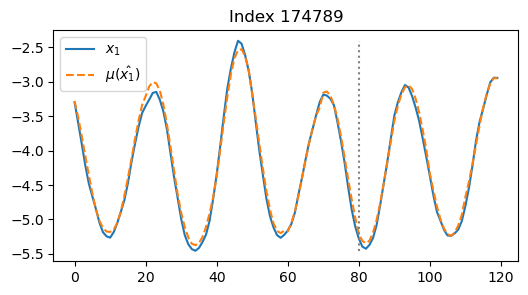

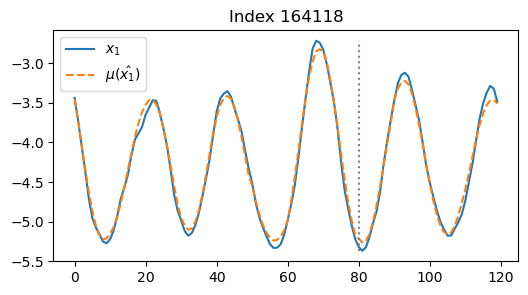

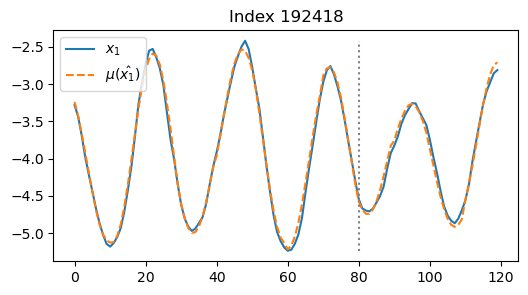

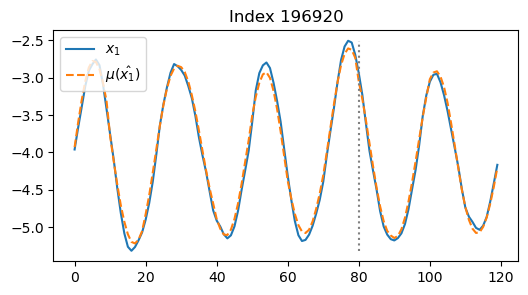

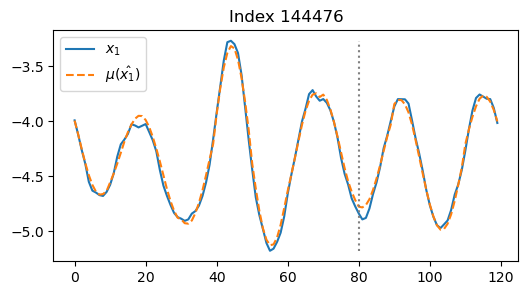

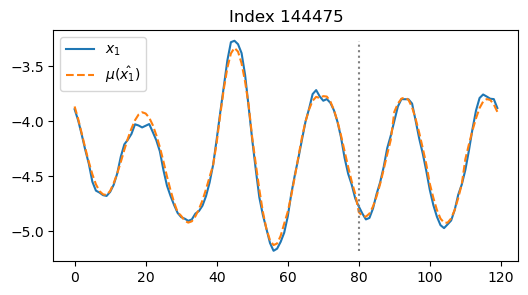

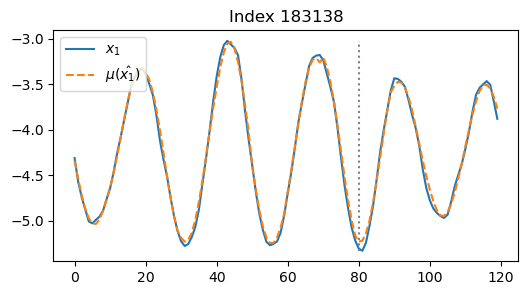

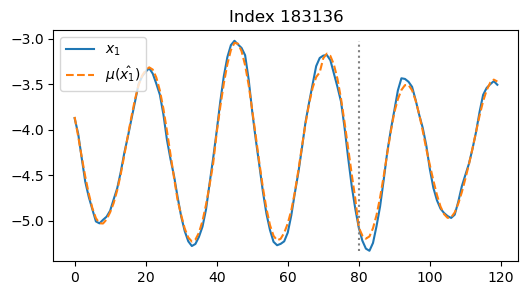

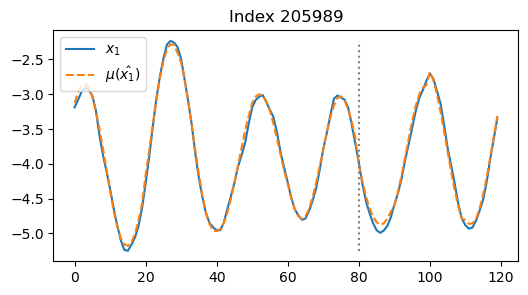

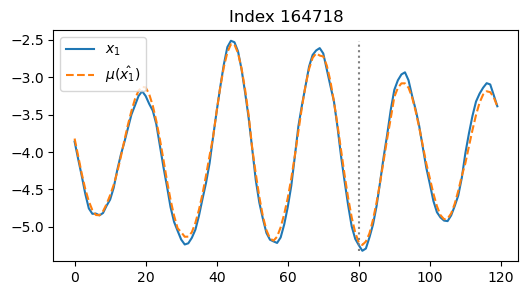

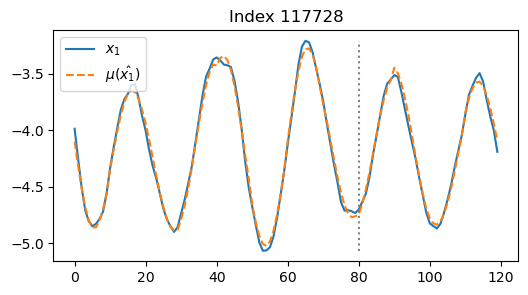

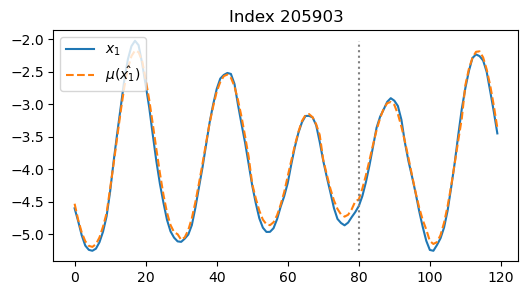

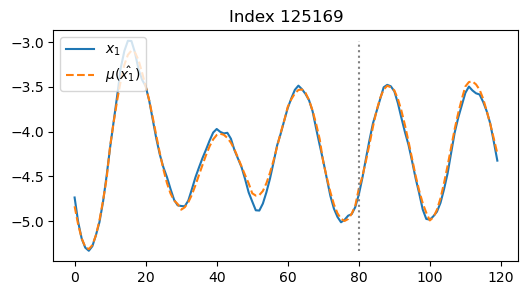

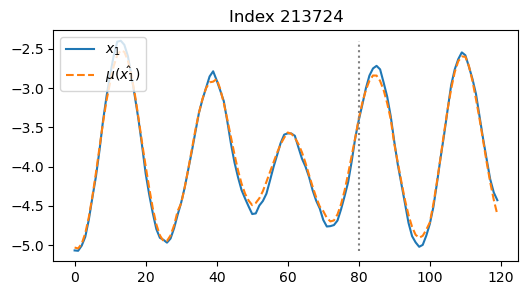

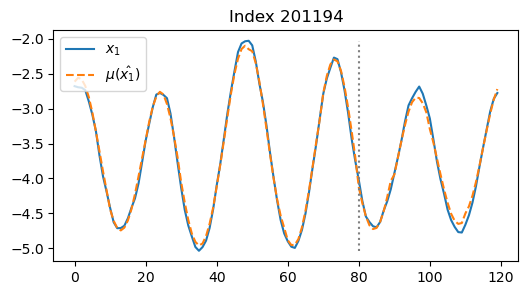

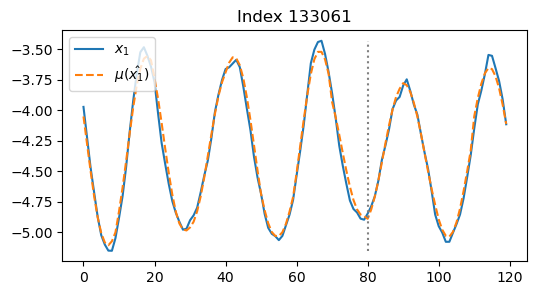

In [9]:
utils_plot.plot_mse_extreme2(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    k=50,
    jsave=159_585,
    datasaved=True, savedir='../../savedata/baselines/tesla')